Dataset import

/images -> raw images of the dataset

/fixations -> binary map. 1 where users pointed at saliency point

/maps -> continous version of the fixation, values from 0 to 255, interpolated from fixations

Note: the same 12 long id identifies a sample across images, fixations and maps

!pip install kaggle
!kaggle datasets download -d roshan401/salicon \
  -p ./datasets/salicon --unzip

./datasets/salicon 3 0
./datasets/salicon/fixations 3 0
./datasets/salicon/fixations/train 0 10000
./datasets/salicon/fixations/val 0 5000
./datasets/salicon/fixations/test 0 5000
./datasets/salicon/images 1 0
./datasets/salicon/images/images 3 0
./datasets/salicon/images/images/train 0 10000
./datasets/salicon/images/images/val 0 5000
./datasets/salicon/images/images/test 0 5000
./datasets/salicon/maps 2 0
./datasets/salicon/maps/train 0 10000
./datasets/salicon/maps/val 0 5000
Image size : (640, 480)
Map size : (640, 480)
RGB
L
uint8 0 255


Text(0.5, 1.0, 'Saliency')

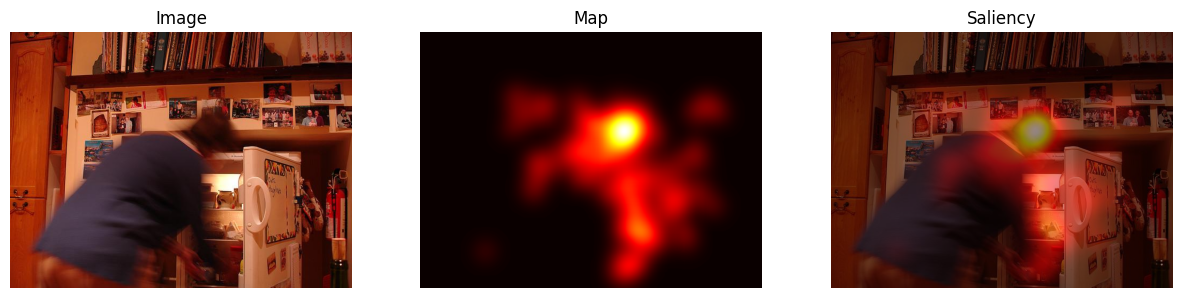

In [52]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
from matplotlib import image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
from torch import nn
from torchinfo import summary
from torch.optim import Adam
import torch.nn.functional as F
from torchvision.transforms import functional as TF

seed = np.random.seed(42)
random.seed(42)

root = './datasets/salicon'
os.walk(root)

for dirpath, dirnames, filenames in os.walk(root):
    print(dirpath, len(dirnames), len(filenames))

TRAIN_DIR = Path(root) / "images/images"
FIX_DIR = Path(root) / "fixations"
MAP_DIR = Path(root) / "maps"

img1 = Image.open(root + '/images/images/train/COCO_train2014_000000096723.jpg')
img2 = Image.open(root + '/maps/train/COCO_train2014_000000096723.png')

print(f"Image size : {img1.size}")
print(f"Map size : {img2.size}")
print(img1.mode)
print(img2.mode)

c = np.array(img2)
print(c.dtype, c.min(), c.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img1); axes[0].axis("Off"); axes[0].set_title("Image")

axes[1].imshow(img2, cmap="hot"); axes[1].axis("Off"); axes[1].set_title("Map")

axes[2].imshow(img1); axes[2].imshow(img2, cmap="hot", alpha=0.5); axes[2].axis("Off"); axes[2].set_title("Saliency")


In [53]:
#Prepare training data paths
image_paths_train = []
map_paths_train = []
stem_dict = {}

for f in os.listdir(MAP_DIR / 'train'):
  stem = Path(f).stem
  stem_dict[stem] = f

for f in os.listdir(TRAIN_DIR / 'train'):
  stem = Path(f).stem
  if stem in stem_dict:
    image_paths_train.append(TRAIN_DIR / 'train'/ f)
    map_paths_train.append(MAP_DIR /'train'/ stem_dict[stem])

print(f"Train size: {len(image_paths_train)}")
print(f"Train size: {len(map_paths_train)}")

#Prepare val/test
image_paths_val_full = []
map_paths_val_full = []
stem_dict = {}

for f in os.listdir(MAP_DIR / 'val'):
  stem = Path(f).stem
  stem_dict[stem] = f

for f in os.listdir(TRAIN_DIR / 'val'):
  stem = Path(f).stem
  if stem in stem_dict:
    image_paths_val_full.append(TRAIN_DIR / 'val'/ f)
    map_paths_val_full.append(MAP_DIR / 'val'/ stem_dict[stem])

idx = list(range(len(image_paths_val_full)))
random.shuffle(idx)

val_idx, test_idx = idx[:3500], idx[3500:]

image_paths_val = [image_paths_val_full[i] for i in val_idx]
image_paths_test = [image_paths_val_full[i] for i in test_idx]
map_paths_val = [map_paths_val_full[i] for i in val_idx]
map_paths_test = [map_paths_val_full[i] for i in test_idx]

print(f"Val size: {len(image_paths_val)}")
print(f"Test size: {len(image_paths_test)}")

Train size: 10000
Train size: 10000
Val size: 3500
Test size: 1500


In [54]:
class ImageDataset(Dataset):

  def __init__(self, image_paths, map_paths, image_size=(256, 256), train=False):

    self.train = train
    
    if len(image_paths) != len(map_paths):
      raise ValueError("Number of images and maps must be the same")

    self.image_paths = image_paths
    self.map_paths = map_paths
    self.image_size = image_size

    self.image_transform = Compose([
        Resize(self.image_size),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    self.map_transform = Compose([
        Resize(self.image_size),
        ToTensor()
    ])

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, index):
    image_path = self.image_paths[index]
    map_path = self.map_paths[index]

    image = Image.open(image_path).convert("RGB")
    sal = Image.open(map_path).convert("L")

    if self.train:
        
        r = random.random()       
        if r < 0.5:
            image = TF.hflip(image)
            sal = TF.hflip(sal)

        r = random.random()
        if r < 0.3:
            angle = random.uniform(-10, 10)
            image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR)
            sal = TF.rotate(sal, angle, interpolation=TF.InterpolationMode.BILINEAR)
            
        r = random.random()   
        if r < 0.5:
            image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
            image = TF.adjust_contrast(image,   random.uniform(0.8, 1.2))
            image = TF.adjust_saturation(image, random.uniform(0.8, 1.2))
        
    return(self.image_transform(image), self.map_transform(sal))


ATTENZIONE: IN LOCALE SU GPU METTI pin_memory = True


In [55]:
train_ds = ImageDataset(image_paths_train, map_paths_train, train=True)
val_ds = ImageDataset(image_paths_val, map_paths_val, train=False)
test_ds = ImageDataset(image_paths_test, map_paths_test, train=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=8, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=8, pin_memory=True, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=8, pin_memory=True, drop_last=False)

#test:
imgs, sals = next(iter(train_loader))
print(imgs.shape, imgs.dtype)
print(sals.shape, sals.dtype)
print(imgs.min().item(), imgs.max().item())  # dopo Normalize, NON in [0,1]
print(sals.min().item(), sals.max().item())  # in [0,1]

torch.Size([16, 3, 256, 256]) torch.float32
torch.Size([16, 1, 256, 256]) torch.float32
-2.1179039478302 2.640000104904175
0.0 1.0


In [56]:
backbone = models.resnet18()

for name, child in backbone.named_children():
    print(name)

conv1
bn1
relu
maxpool
layer1
layer2
layer3
layer4
avgpool
fc


In [57]:
class encoder(nn.Module):

  def __init__(self):
    super().__init__()

    backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    self.stem = nn.Sequential(
        backbone.conv1,
        backbone.bn1,
        backbone.relu,
        backbone.maxpool
    )
    self.layer1 = backbone.layer1
    self.layer2 = backbone.layer2
    self.layer3 = backbone.layer3
    self.layer4 = backbone.layer4

    #ignore last 2 layers of resnet

  def forward(self, x):
    x = self.stem(x)
    c1 = self.layer1(x)
    c2 = self.layer2(c1)
    c3 = self.layer3(c2)
    c4 = self.layer4(c3)
    return c1, c2, c3, c4

In [58]:
class decoder(nn.Module):

  def __init__(self):

    super().__init__()

    self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
    self.dropout = nn.Dropout2d(0.2)
    self.conv1 = nn.Conv2d(in_channels=768, out_channels=256, kernel_size=3, stride=1, padding=1)
    self.bn1 = nn.BatchNorm2d(256)

    self.conv2 = nn.Conv2d(in_channels=384, out_channels=128, kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(128)

    self.conv3 = nn.Conv2d(in_channels=192, out_channels=64, kernel_size=3, stride=1, padding=1)
    self.bn3 = nn.BatchNorm2d(64)

    self.conv4 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1)
    self.bn4 = nn.BatchNorm2d(32)

    self.conv5 = nn.Conv2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1)

  def forward(self, c1, c2, c3, c4):

    x = self.up(c4)
    x = torch.cat([x, c3], dim=1)
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.dropout(x)
    x = torch.relu(x)

    x = self.up(x)
    x = torch.cat([x, c2], dim=1)
    x = self.conv2(x)
    x = self.bn2(x)
    x = self.dropout(x)
    x = torch.relu(x)

    x = self.up(x)
    x = torch.cat([x, c1], dim=1)
    x = self.conv3(x)
    x = self.bn3(x)
    x = self.dropout(x)
    x = torch.relu(x)

    x = self.up(x)
    x = self.conv4(x)
    x = self.bn4(x)
    x = self.dropout(x)
    x = torch.relu(x)

    x = self.up(x)
    x = self.conv5(x)

    return x

#sanity check
dummy = encoder()
z = torch.zeros((2, 3, 256, 256))
c1, c2, c3, c4 = dummy.forward(z)
print(c1.shape, c2.shape, c3.shape, c4.shape)
f = decoder()
f.forward(c1, c2, c3, c4)


torch.Size([2, 64, 64, 64]) torch.Size([2, 128, 32, 32]) torch.Size([2, 256, 16, 16]) torch.Size([2, 512, 8, 8])


tensor([[[[ 2.8945e-01,  7.5132e-02,  6.9149e-02,  ..., -3.7988e-01,
           -4.1372e-01, -4.8771e-01],
          [ 6.1675e-01,  4.8661e-01,  4.6924e-01,  ..., -4.7006e-01,
           -4.8547e-01, -5.6682e-01],
          [ 5.9295e-01,  5.0634e-01,  5.2657e-01,  ..., -5.6634e-01,
           -5.5429e-01, -5.9645e-01],
          ...,
          [ 6.7366e-01,  5.4054e-01,  4.7846e-01,  ..., -8.1919e-01,
           -6.7596e-01, -4.3241e-01],
          [ 6.5055e-01,  5.7462e-01,  5.5528e-01,  ..., -6.3142e-01,
           -4.8839e-01, -4.0608e-01],
          [ 5.9746e-01,  5.3569e-01,  5.3510e-01,  ...,  1.3448e-01,
            2.3645e-01, -1.4607e-01]]],


        [[[ 2.5344e-01,  5.2719e-03,  2.8558e-05,  ..., -1.8603e-01,
           -2.2038e-01, -4.7824e-01],
          [ 5.0708e-01,  2.4961e-01,  2.3035e-01,  ...,  8.7179e-02,
           -2.4972e-02, -4.0549e-01],
          [ 4.7825e-01,  2.2927e-01,  2.1595e-01,  ...,  1.1324e-01,
            4.1897e-02, -3.6384e-01],
          ...,
   

In [59]:
class SaliencyKLLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred_logits, target):
        B = pred_logits.size(0)
        pred = pred_logits.view(B, -1)
        targ = target.view(B, -1)

        log_pred = F.log_softmax(pred, dim=1)
        targ = targ / (targ.sum(dim=1, keepdim=True) + self.eps)

        return F.kl_div(log_pred, targ, reduction='batchmean')

image_encoder = encoder()
image_decoder = decoder()

loss_fn = SaliencyKLLoss()

params_to_optimize = [
    {'params': image_encoder.parameters(), 'lr': 1e-5},
    {'params': image_decoder.parameters(), 'lr': 1e-4},
]
optim = torch.optim.Adam(params_to_optimize, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='min', factor=0.5, patience=3, min_lr=1e-7)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Selected device: {device}')

image_encoder.to(device)
image_decoder.to(device)

Selected device: cuda


decoder(
  (up): Upsample(scale_factor=2.0, mode='bilinear')
  (dropout): Dropout2d(p=0.2, inplace=False)
  (conv1): Conv2d(768, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [60]:
# Training function
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer):
    encoder.train()
    decoder.train()
    losses = []
    for image_batch, image_map_batch in dataloader:
        
        image_batch = image_batch.to(device)
        
        image_map_batch = image_map_batch.to(device)
        
        c1, c2, c3, c4 = encoder(image_batch)

        decoded_data = decoder(c1, c2, c3, c4)

        loss = loss_fn(decoded_data, image_map_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.detach().cpu().numpy())
    losses = np.mean(losses)
    return losses

In [61]:
def test_epoch(encoder, decoder, device, dataloader, loss_fn):
    encoder.eval()
    decoder.eval()
    val_losses = []
    
    with torch.no_grad():
        for image_batch, image_map_batch in dataloader:
            image_batch = image_batch.to(device)
            image_map_batch = image_map_batch.to(device)
            
            c1, c2, c3, c4 = encoder(image_batch)
            decoded_data = decoder(c1, c2, c3, c4)

            loss = loss_fn(decoded_data, image_map_batch)
            val_losses.append(loss.item())

    return np.mean(val_losses)

EPOCH 1/50
TRAIN - EPOCH 1/50 - loss: 0.36300668120384216
VALIDATION - EPOCH 1/50 - loss: 0.2615831260267458



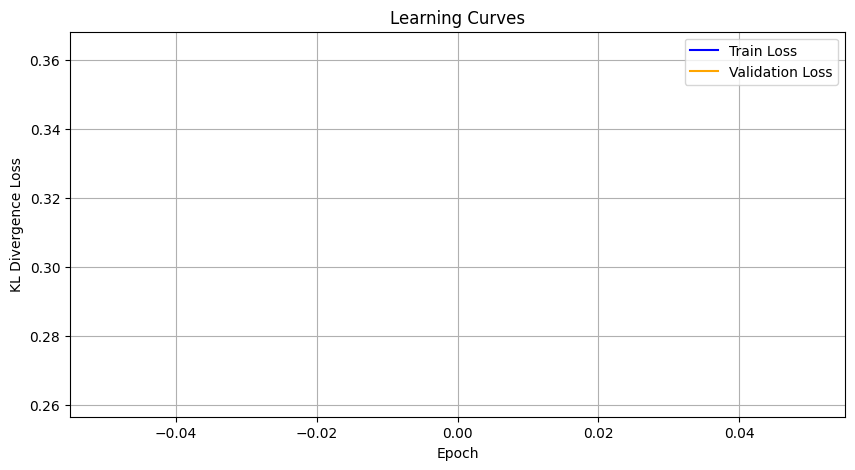

EPOCH 2/50
TRAIN - EPOCH 2/50 - loss: 0.28568002581596375
VALIDATION - EPOCH 2/50 - loss: 0.24995570687670685



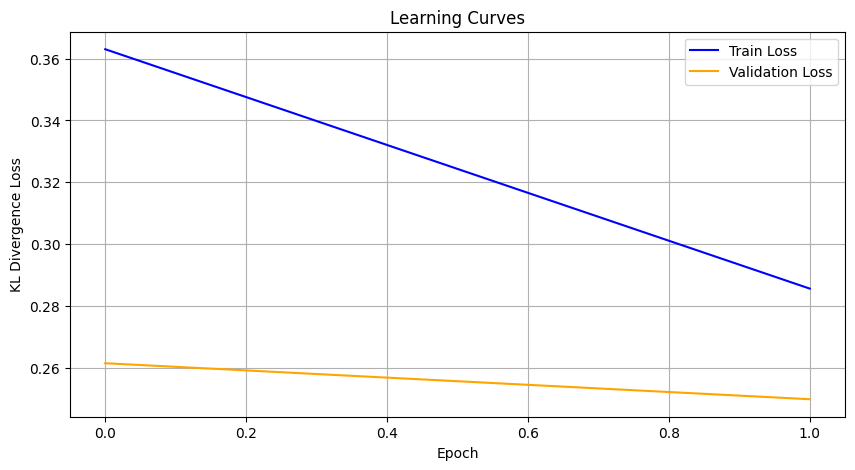

EPOCH 3/50
TRAIN - EPOCH 3/50 - loss: 0.2669045627117157
VALIDATION - EPOCH 3/50 - loss: 0.24465187302190963



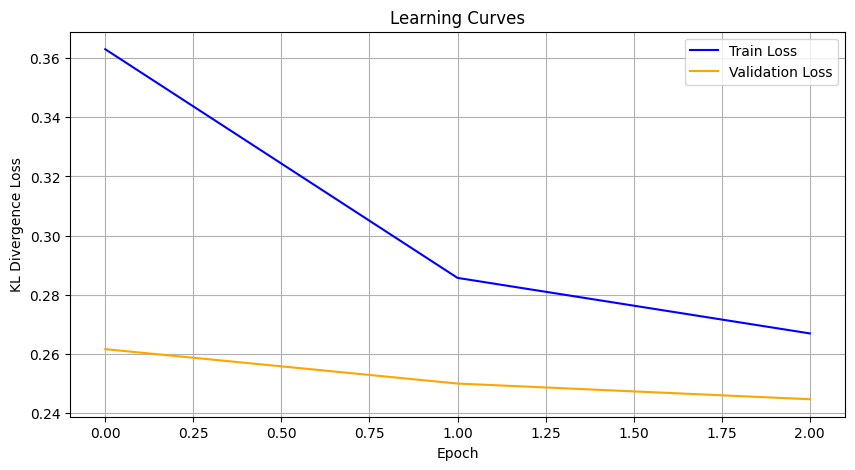

EPOCH 4/50
TRAIN - EPOCH 4/50 - loss: 0.2535119652748108
VALIDATION - EPOCH 4/50 - loss: 0.2438410346366499



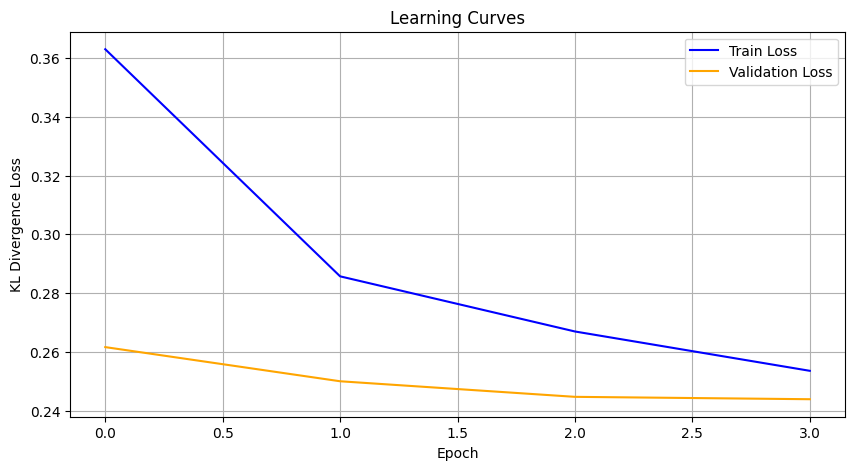

EPOCH 5/50
TRAIN - EPOCH 5/50 - loss: 0.24531814455986023
VALIDATION - EPOCH 5/50 - loss: 0.2375949803552671



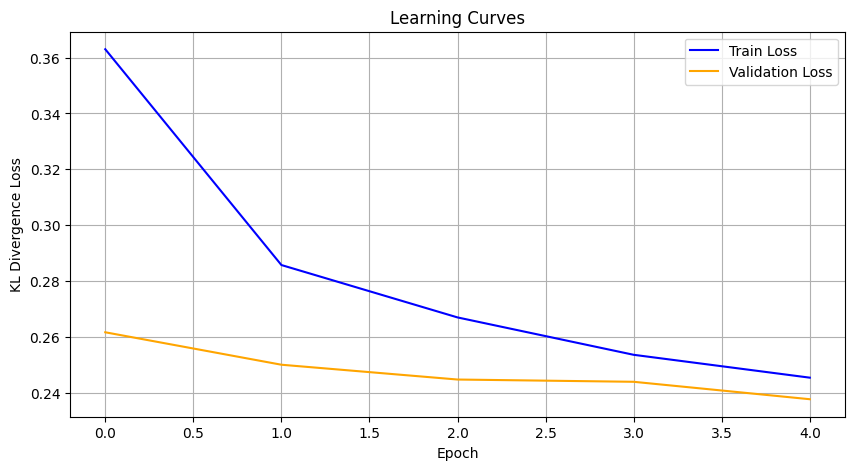

EPOCH 6/50
TRAIN - EPOCH 6/50 - loss: 0.2354513257741928
VALIDATION - EPOCH 6/50 - loss: 0.2390325476317645



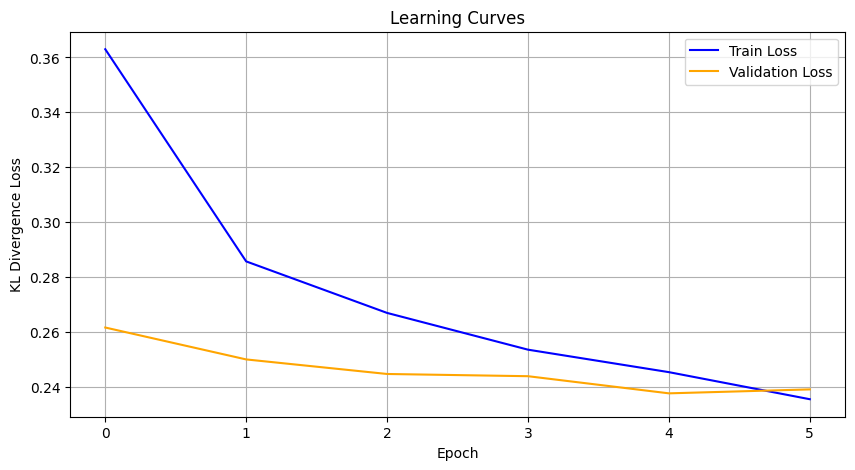

EPOCH 7/50
TRAIN - EPOCH 7/50 - loss: 0.22779850661754608
VALIDATION - EPOCH 7/50 - loss: 0.23232074340456696



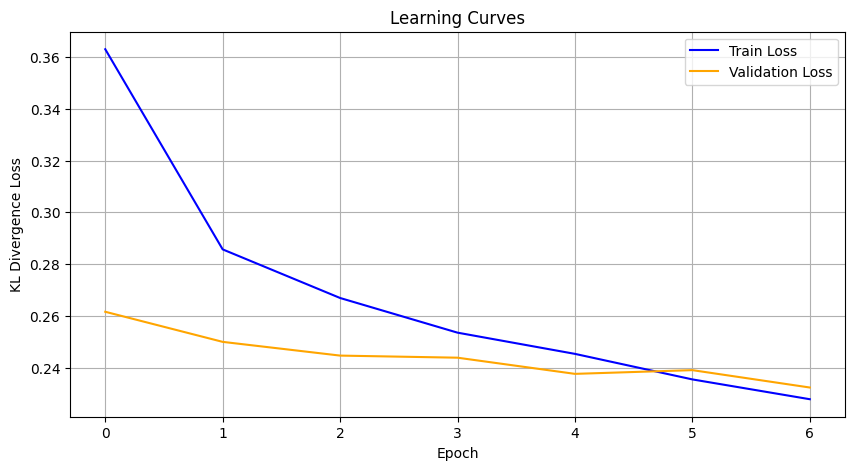

EPOCH 8/50
TRAIN - EPOCH 8/50 - loss: 0.2203863263130188
VALIDATION - EPOCH 8/50 - loss: 0.231076570814603



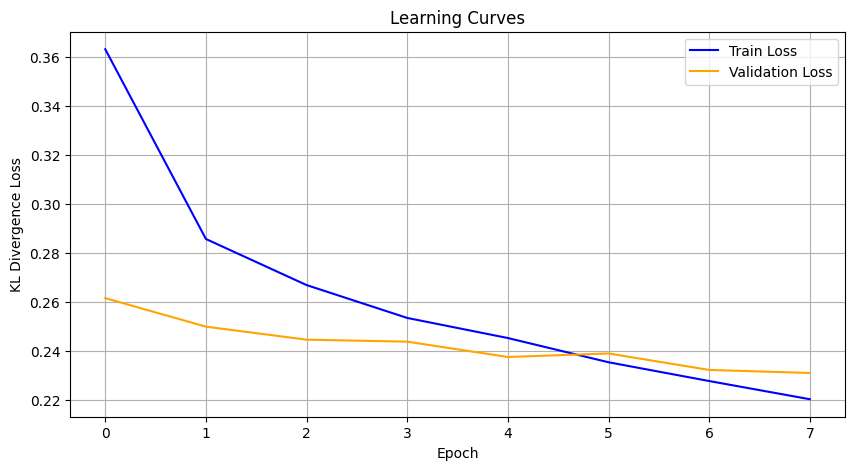

EPOCH 9/50
TRAIN - EPOCH 9/50 - loss: 0.21367260813713074
VALIDATION - EPOCH 9/50 - loss: 0.23078862451799384



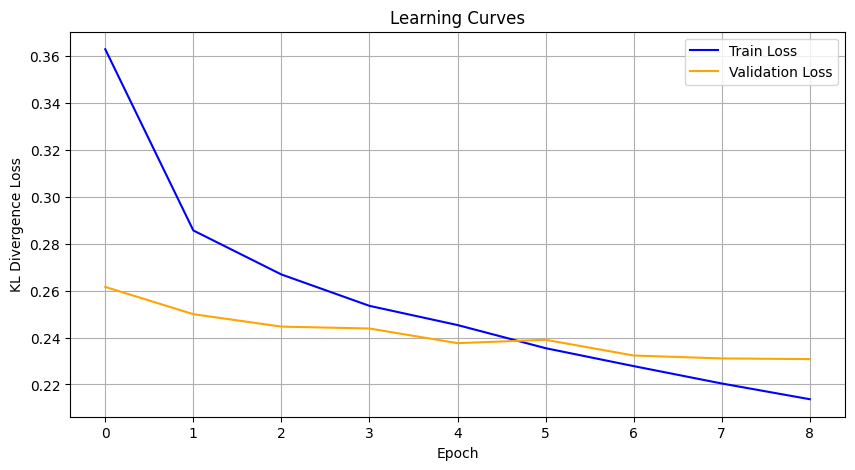

EPOCH 10/50
TRAIN - EPOCH 10/50 - loss: 0.2076934576034546
VALIDATION - EPOCH 10/50 - loss: 0.23596560737313746



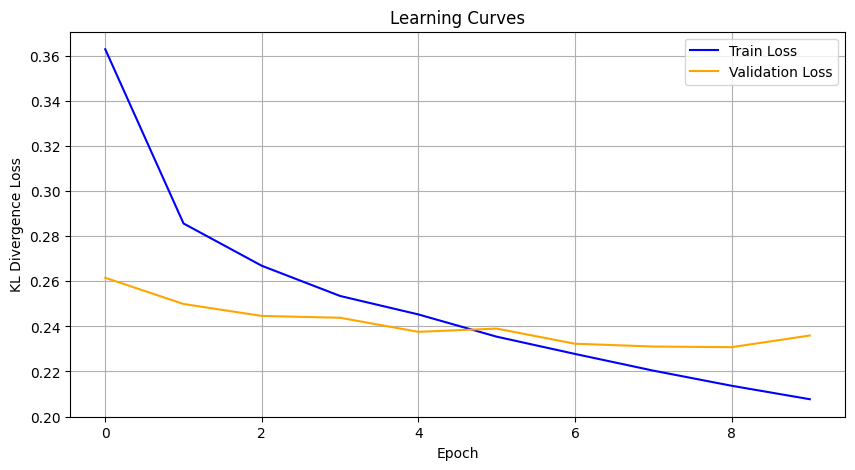

EPOCH 11/50
TRAIN - EPOCH 11/50 - loss: 0.20217275619506836
VALIDATION - EPOCH 11/50 - loss: 0.23428422927039944



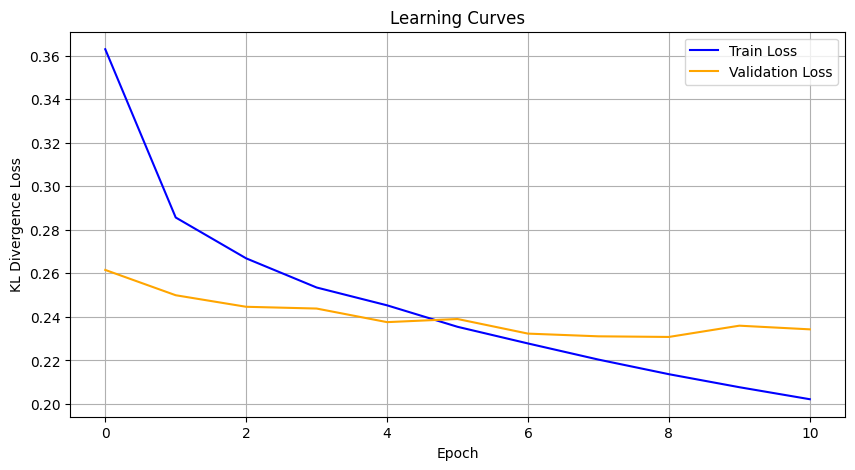

EPOCH 12/50


In [ ]:
num_epochs = 50
train_loss_history = []
val_loss_history = []
bad, patience = 0, 7
best_val_error = float('inf')

for epoch in range(num_epochs):
    print('EPOCH %d/%d' % (epoch + 1, num_epochs))
    ### Training (use the training function)
    train_loss = train_epoch(
        encoder=image_encoder,
        decoder=image_decoder,
        device=device,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optim)
    print(f'TRAIN - EPOCH {epoch+1}/{num_epochs} - loss: {train_loss}')

    ### Validation  (use the testing function)
    val_loss = test_epoch(
        encoder=image_encoder,
        decoder=image_decoder,
        device=device,
        dataloader=val_loader,
        loss_fn=loss_fn)
    
    scheduler.step(val_loss)
    
    # Print Validation curves
    print(f'VALIDATION - EPOCH {epoch+1}/{num_epochs} - loss: {val_loss}\n')
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    plt.figure(figsize=(10, 5))
    plt.plot(train_loss_history, label='Train Loss', color='blue')
    plt.plot(val_loss_history, label='Validation Loss', color='orange')
    plt.title('Learning Curves')
    plt.xlabel('Epoch')
    plt.ylabel('KL Divergence Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    if best_val_error > val_loss:
        best_val_error = val_loss
        bad = 0
        torch.save({"encoder" : image_encoder.state_dict(), "decoder" : image_decoder.state_dict()}, 'best.pt')
    else:
        bad += 1
        if bad == patience:
            break
        
